# IPL 2025 STATS

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')
sns.set_palette('Set2')

In [5]:
batters= pd.read_csv('IPL2025Batters.csv')
bowlers= pd.read_csv('IPL2025Bowlers.csv')
batters.index=batters.index + 1
bowlers.index=bowlers.index + 1

***batsman stats***

In [30]:
batters

,Player Name,Team,Runs,Matches,Inn,No,HS,AVG,BF,SR,100s,50s,4s,6s,Runs_per_Match
1,Sai Sudharsan,GT,759,15,15,1,108*,54.21,486,156.17,1,6,88,21,50.600000
2,Surya Kumar Yadav,MI,717,16,16,5,73*,65.18,427,167.91,0,5,69,38,44.812500
3,Virat Kohli,RCB,657,15,15,3,73*,54.75,454,144.71,0,8,66,19,43.800000
4,Shubman Gill,GT,650,15,15,2,93*,50.00,417,155.87,0,6,62,24,43.333333
5,Mitchell Marsh,LSG,627,13,13,0,117,48.23,383,163.70,1,6,56,37,48.230769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Khaleel Ahmed,CSK,1,14,2,2,1*,-,2,50.00,0,0,0,0,0.071429
153,Mohit Sharma,DC,1,8,2,1,1*,1.00,3,33.33,0,0,0,0,0.125000
154,Donovan Ferreira,DC,1,1,1,0,1,1.00,3,33.33,0,0,0,0,1.000000
155,Digvesh Singh,LSG,1,13,2,1,1,1.00,3,33.33,0,0,0,0,0.076923


***bowlers stats***

In [31]:
bowlers

,Player Name,Team,WKT,MAT,INN,OVR,RUNS,BBI,AVG,ECO,SR,4W,5W
1,Prasidh Krishna,GT,25,15,15,59.0,488,41/4,19.52,8.27,14.16,1,0
2,Noor Ahmad,CSK,24,14,14,50.0,408,18/4,17.00,8.16,12.50,2,0
3,Josh Hazlewood,RCB,22,12,12,44.0,386,33/4,17.54,8.77,12.00,1,0
4,Trent Boult,MI,22,16,16,57.4,517,26/4,23.50,8.96,15.72,1,0
5,Arshdeep Singh,PBKS,21,17,16,58.2,518,16/3,24.66,8.88,16.66,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,Marcus Stoinis,PBKS,1,13,9,14.1,175,14/1,175.00,12.35,85.00,0,0
105,Shahrukh Khan,GT,1,15,1,1.0,13,13/1,13.00,13.00,6.00,0,0
106,V Satyanarayana Penmetsa,MI,1,2,2,4.0,53,40/1,53.00,13.25,24.00,0,0
107,Musheer Khan,PBKS,1,1,1,2.0,27,27/1,27.00,13.50,12.00,0,0


***explore the data***

In [10]:
print("Batters Shape:", batters.shape)
print("Bowlers Shape:", bowlers.shape)

batters.info()
bowlers.info()


Batters Shape: (156, 14)
Bowlers Shape: (108, 13)
<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 1 to 156
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player Name  156 non-null    str    
 1   Team         156 non-null    str    
 2   Runs         156 non-null    int64  
 3   Matches      156 non-null    int64  
 4   Inn          156 non-null    int64  
 5   No           156 non-null    int64  
 6   HS           156 non-null    str    
 7   AVG          156 non-null    str    
 8   BF           156 non-null    int64  
 9   SR           156 non-null    float64
 10  100s         156 non-null    int64  
 11  50s          156 non-null    int64  
 12  4s           156 non-null    int64  
 13  6s           156 non-null    int64  
dtypes: float64(1), int64(9), str(4)
memory usage: 17.2 KB
<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 1 to 108
Data columns (total 13 columns):
 #   Column       Non-Null Coun

In [11]:
# Missing values check
batters.isnull().sum(), bowlers.isnull().sum()

(Player Name    0
 Team           0
 Runs           0
 Matches        0
 Inn            0
 No             0
 HS             0
 AVG            0
 BF             0
 SR             0
 100s           0
 50s            0
 4s             0
 6s             0
 dtype: int64,
 Player Name    0
 Team           0
 WKT            0
 MAT            0
 INN            0
 OVR            0
 RUNS           0
 BBI            0
 AVG            0
 ECO            0
 SR             0
 4W             0
 5W             0
 dtype: int64)

In [12]:
# Duplicate rows check
batters.duplicated().sum(), bowlers.duplicated().sum()


(np.int64(0), np.int64(0))

In [13]:
batters.columns

Index(['Player Name', 'Team', 'Runs', 'Matches', 'Inn', 'No', 'HS', 'AVG',
       'BF', 'SR', '100s', '50s', '4s', '6s'],
      dtype='str')

## Top 10 Runs Scorer-2025

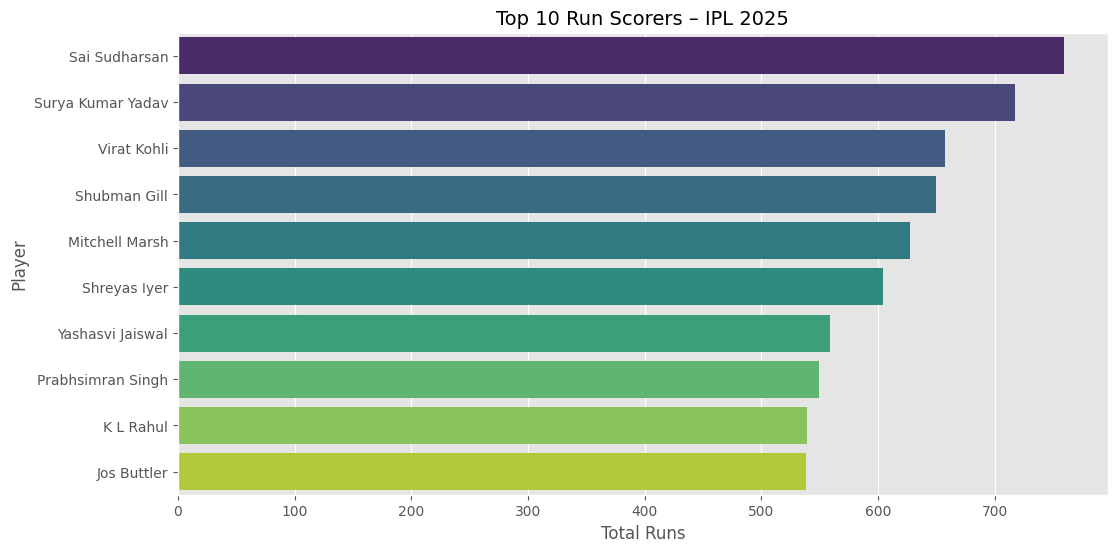

In [14]:
top_run_scorers = batters.sort_values(by='Runs', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_run_scorers,
    x='Runs',
    y='Player Name',
    hue='Player Name',
    palette='viridis',
    legend=False
)
plt.title("Top 10 Run Scorers – IPL 2025", fontsize=14)
plt.xlabel("Total Runs")
plt.ylabel("Player")
plt.show()

## Strike Rate vs Runs by Batsman

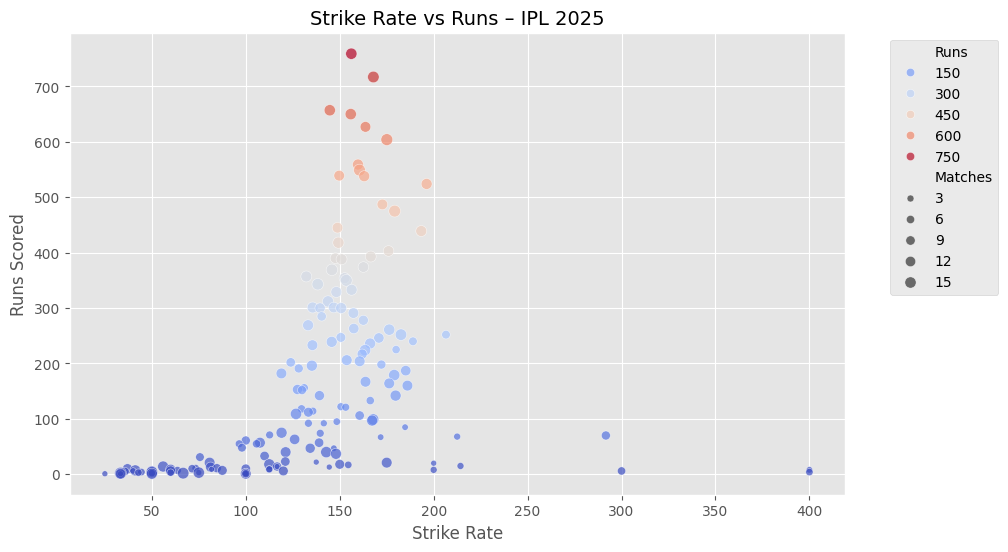

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=batters,
    x='SR',
    y='Runs',
    size='Matches',
    hue='Runs',
    palette='coolwarm',
    alpha=0.7
)
plt.title("Strike Rate vs Runs – IPL 2025", fontsize=14)
plt.xlabel("Strike Rate")
plt.ylabel("Runs Scored")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## top 10 consistent batters per match

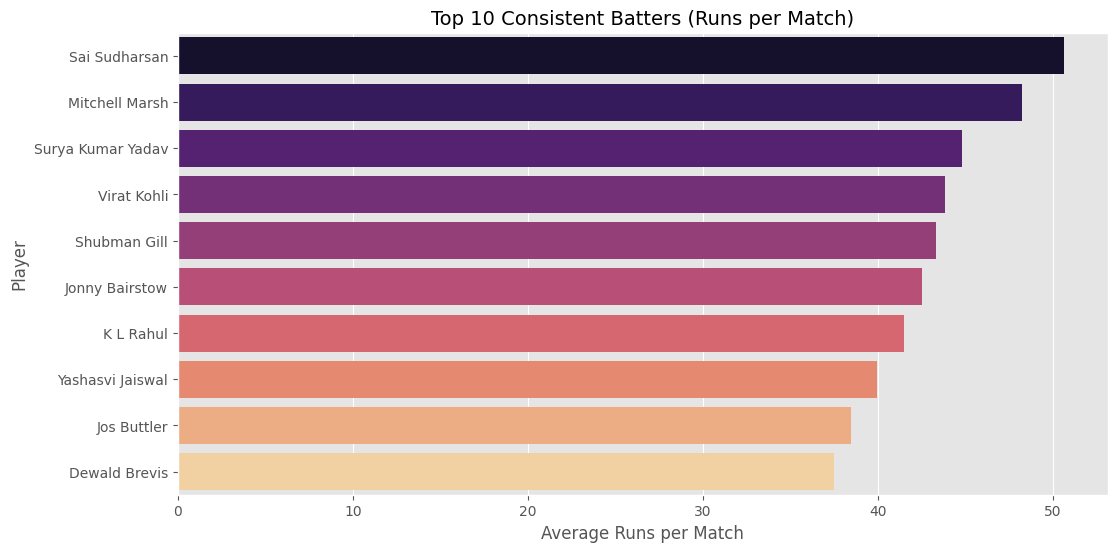

In [23]:
batters['Runs_per_Match'] = batters['Runs'] / batters['Matches']

top_consistent = batters.sort_values('Runs_per_Match', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_consistent,
    x='Runs_per_Match',
    y='Player Name',
    hue='Player Name',
    palette='magma'
)
plt.title("Top 10 Consistent Batters (Runs per Match)", fontsize=14)
plt.xlabel("Average Runs per Match")
plt.ylabel("Player")
plt.show()

## Top 10 Wicket Takers

In [24]:
bowlers.columns

Index(['Player Name', 'Team', 'WKT', 'MAT', 'INN', 'OVR', 'RUNS', 'BBI', 'AVG',
       'ECO', 'SR', '4W', '5W'],
      dtype='str')

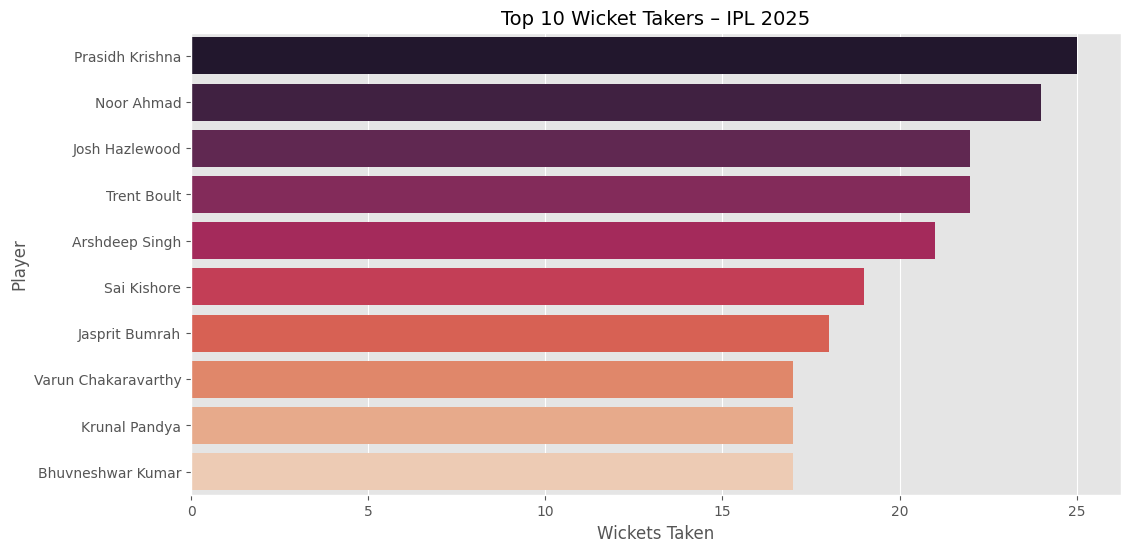

In [25]:
top_wicket_takers = bowlers.sort_values(by='WKT', ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_wicket_takers,
    x='WKT',
    y='Player Name',
    hue='Player Name',
    palette='rocket'
)
plt.title("Top 10 Wicket Takers – IPL 2025", fontsize=14)
plt.xlabel("Wickets Taken")
plt.ylabel("Player")
plt.show()

## Economy Rate vs Wickets

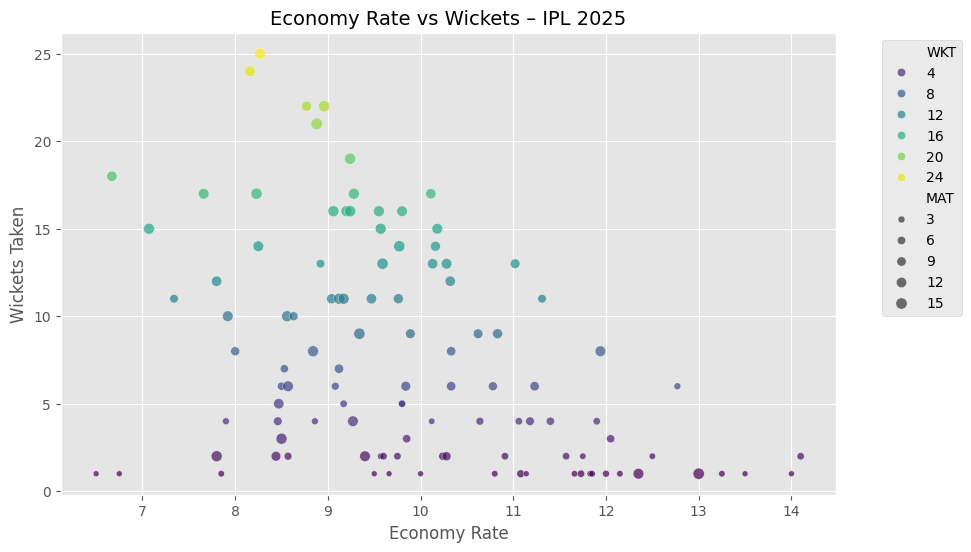

In [26]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=bowlers,
    x='ECO',
    y='WKT',
    size='MAT',
    hue='WKT',
    palette='viridis',
    alpha=0.7
)
plt.title("Economy Rate vs Wickets – IPL 2025", fontsize=14)
plt.xlabel("Economy Rate")
plt.ylabel("Wickets Taken")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Top 10 AllRounder Impact player

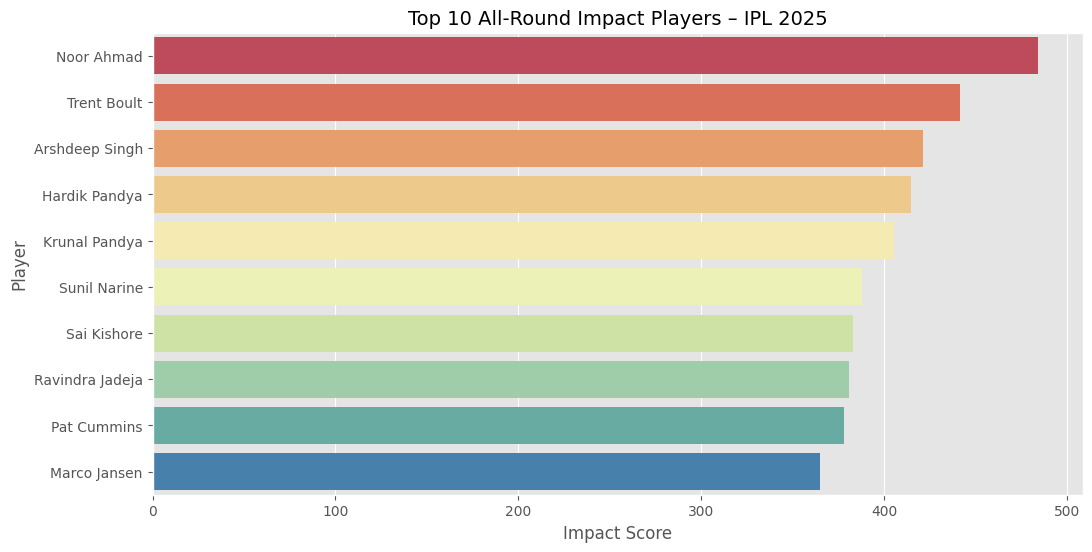

In [29]:
bat_impact = batters[['Player Name', 'Runs']].copy()
bowl_impact = bowlers[['Player Name', 'WKT']].copy()

impact_df = pd.merge(bat_impact, bowl_impact, on='Player Name', how='inner')

impact_df.head()
impact_df['Impact_Score'] = (
    impact_df['Runs'] * 0.6 + impact_df['WKT'] * 20
)

top_allrounders = impact_df.sort_values(
    by='Impact_Score', ascending=False
).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_allrounders,
    x='Impact_Score',
    y='Player Name',
    hue='Player Name',
    palette='Spectral'
)
plt.title("Top 10 All-Round Impact Players – IPL 2025", fontsize=14)
plt.xlabel("Impact Score")
plt.ylabel("Player")
plt.show()